In [1]:
# Cargamos la librerías que vamos a necesitar para poder abordar el problema
import numpy as np
import pandas as pd
import torch
from torch import nn
import time
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/alumnos/davidase/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def modelo3D(t, z, λ, K, β, γ, b, δ):
  x, y, v = z

  # Sistema dinámico simplificado (Tian 2011: βv = βy = 0)
  dx = λ * x * (1 - (x + y) / K) - β * x * v
  dy = β * x * v - γ * y
  dv = -β * x * v + b * γ * y - δ * v

  return [dx, dy, dv]

In [3]:
def model_adim(t, z, r, a, b, c):
    x, y, v = z
    dx = r * x * (1 - x - y) - a * x * v
    dy = a * x * v - y
    dv = b * y - a * x * v - c * v
    return [dx, dy, dv]

## Parámetros del modelo y condiciones iniciales

In [4]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
r = 0.36    # Tasa de crecimiento tumoral
a = 0.11    # Tasa de infección adimensional
c = 0.2     # Tasa de eliminación del virus

# Valor VERDADERO de b (tamaño de explosión viral) — lo que la PINN debe estimar
b_true = 9.0

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

## Generación de datos sintéticos de entrenamiento

Simulamos el sistema con el valor verdadero `b_true` para obtener observaciones
a las que añadimos ruido gaussiano. Estas observaciones son los "datos clínicos"
que la PINN usará para estimar `b`.

In [5]:
torch.manual_seed(42)
np.random.seed(42)

# Número de puntos de observación
N_OBS = 100

# Tiempos de observación distribuidos uniformemente en [0, TAU_MAX]
t_obs_np = np.linspace(0, TAU_MAX, N_OBS)

# Solución de referencia con b_true
sol_data = solve_ivp(
    model_adim,
    [0, TAU_MAX],
    [x0, y0, v0],
    args=(r, a, b_true, c),
    t_eval=t_obs_np,
    method='LSODA',
    rtol=1e-8, atol=1e-10
)

# Nivel de ruido relativo
noise_level = 0.0

x_clean = sol_data.y[0]
y_clean = sol_data.y[1]
v_clean = sol_data.y[2]

x_noisy = x_clean + noise_level * np.std(x_clean) * np.random.randn(N_OBS)
y_noisy = y_clean + noise_level * np.std(y_clean) * np.random.randn(N_OBS)
v_noisy = v_clean + noise_level * np.std(v_clean) * np.random.randn(N_OBS)

# Convertimos a tensores de PyTorch
t_data   = torch.tensor(t_obs_np,  dtype=torch.float32).view(-1, 1)
x_data   = torch.tensor(x_noisy,   dtype=torch.float32).view(-1, 1)
y_data   = torch.tensor(y_noisy,   dtype=torch.float32).view(-1, 1)
v_data   = torch.tensor(v_noisy,   dtype=torch.float32).view(-1, 1)

print(f"Datos generados: {N_OBS} observaciones en t ∈ [0, {TAU_MAX}]")
print(f"Valor verdadero de b: {b_true}")

Datos generados: 100 observaciones en t ∈ [0, 200.0]
Valor verdadero de b: 9.0


## Visualización de los datos de entrenamiento

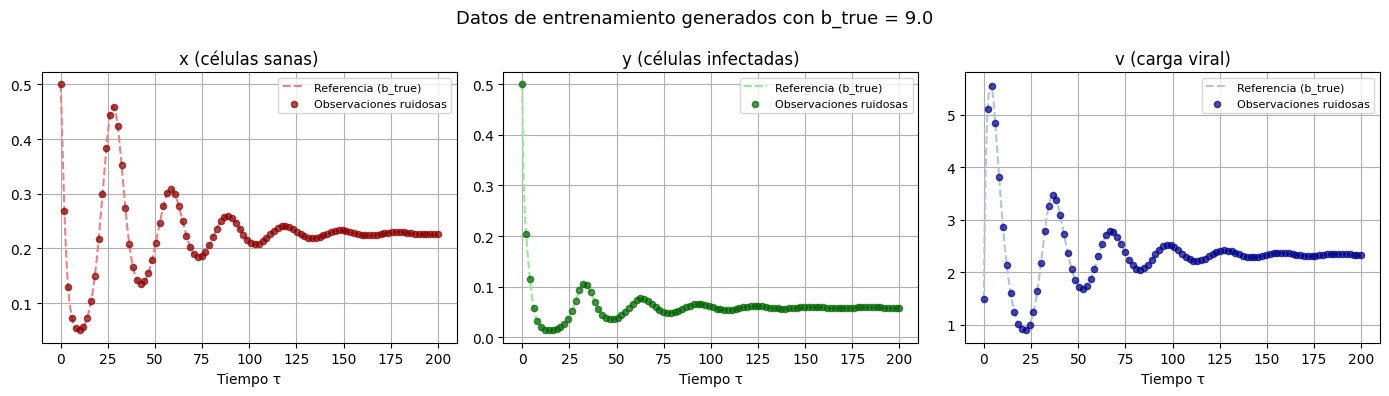

In [6]:
t_ref_np = np.linspace(0, TAU_MAX, 500)
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r, a, b_true, c), t_eval=t_ref_np, method='LSODA'
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_var = ['x (células sanas)', 'y (células infectadas)', 'v (carga viral)']
colors_ref = ['lightcoral', 'lightgreen', 'lightsteelblue']
colors_data = ['darkred', 'darkgreen', 'darkblue']

for i, ax in enumerate(axes):
    ax.plot(t_ref_np, sol_ref.y[i], '--', color=colors_ref[i], label='Referencia (b_true)')
    noisy = [x_noisy, y_noisy, v_noisy][i]
    ax.scatter(t_obs_np, noisy, s=20, color=colors_data[i], alpha=0.7, zorder=5, label='Observaciones ruidosas')
    ax.set_xlabel('Tiempo τ')
    ax.set_title(labels_var[i])
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(f'Datos de entrenamiento generados con b_true = {b_true}', fontsize=13)
plt.tight_layout()
plt.show()

## Arquitectura de la PINN

In [7]:
class VIRO_NN(nn.Module):
    """Red neuronal para el problema inverso de viroterapia.
    
    Aproxima la solución (x(t), y(t), v(t)) del sistema adimensionalizado
    de Tian mientras co-estima el parámetro b (tamaño de explosión viral).
    """

    def __init__(self, N_HIDDEN, N_LAYERS, x0=0.5, y0=0.5, v0=1.5):
        super().__init__()
        activation = nn.SiLU  # Tanh: gradientes suaves, adecuada para PINNs

        self.x0 = x0
        self.y0 = y0
        self.v0 = v0

        N_INPUT  = 1
        N_OUTPUT = 3

        # Capa de entrada
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        # Capas ocultas
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)
        ])
        # Capa de salida
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, t):
        # Normalización al intervalo [0, 1]
        tau = t / TAU_MAX

        out = self.fcs(tau)
        out = self.fch(out)
        out = self.fce(out)

        # Ansatz: garantiza condiciones iniciales exactas
        x = self.x0 + tau * out[:, 0:1]
        y = self.y0 + tau * out[:, 1:2]
        v = self.v0 + tau * out[:, 2:3]

        return torch.cat([x, y, v], dim=1)

## Problema inverso: estimación de `b` como parámetro aprendible

Siguiendo la misma estrategia que en el oscilador armónico amortiguado,
tratamos `b` como un `nn.Parameter` y lo incluimos en el optimizador.
La función de pérdida combina:

- **Pérdida física** `L_phys`: residuo de las EDOs del modelo de Tian en puntos de colocación.
- **Pérdida de datos** `L_data`: MSE entre la predicción de la red y las observaciones ruidosas.

$$\mathcal{L} = \mathcal{L}_{\text{phys}} + \lambda \cdot \mathcal{L}_{\text{data}}$$

Iniciando entrenamiento: b_init = 1.0000 | b_true = 9.0
Épocas: 30001 | Puntos físicos: 1000 | Observaciones: 100

Época      0 | Loss: 14715.515625 (phys: 0.191353, data: 1.471532) | b_est = 0.9990 | t: 0.2s


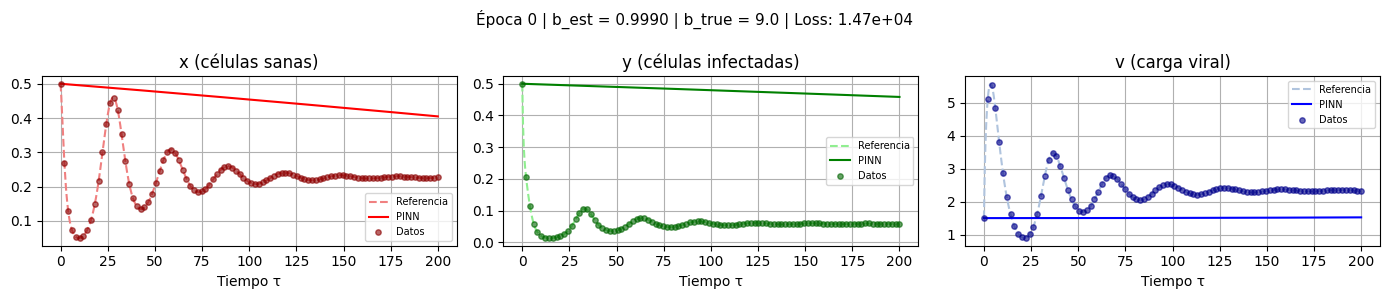

Época   5000 | Loss: 16.220711 (phys: 0.036432, data: 0.001618) | b_est = 5.5394 | t: 96.1s


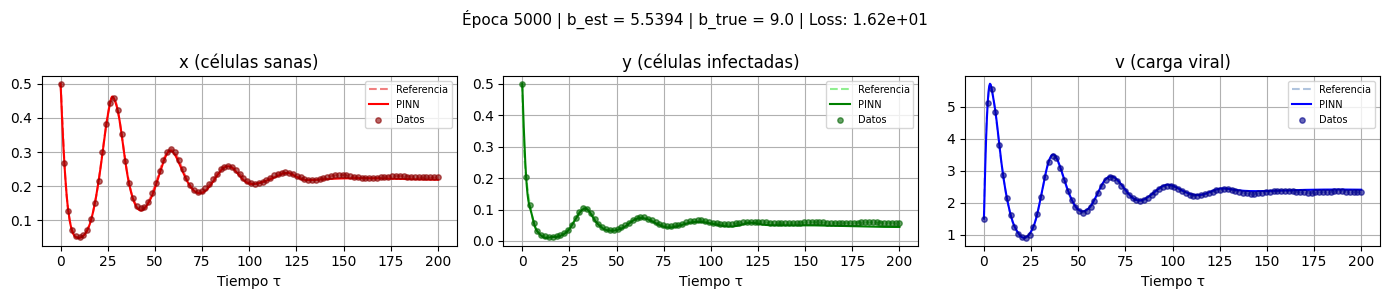

Época  10000 | Loss: 0.311734 (phys: 0.005337, data: 0.000031) | b_est = 8.4120 | t: 195.9s


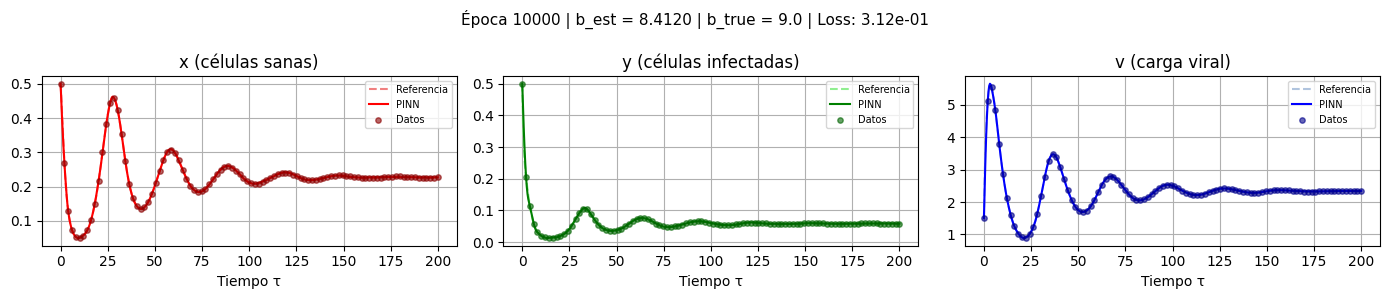

Época  15000 | Loss: 1.205045 (phys: 0.005324, data: 0.000120) | b_est = 8.6018 | t: 297.0s


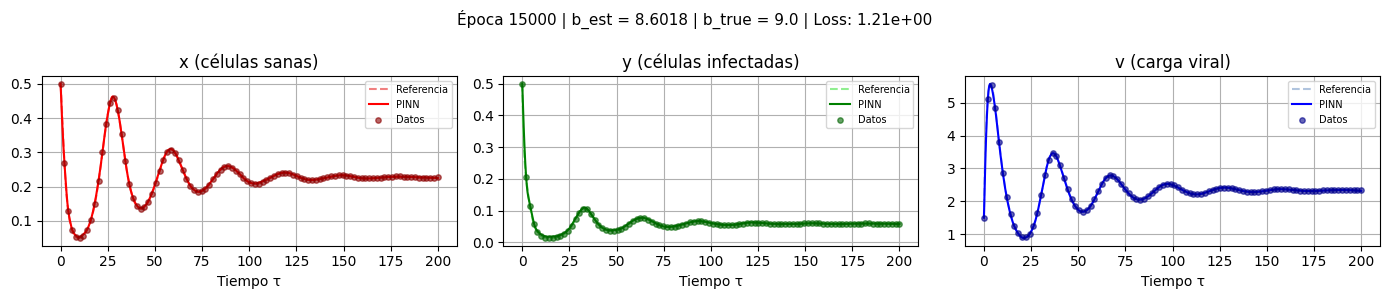

Época  20000 | Loss: 0.074648 (phys: 0.004595, data: 0.000007) | b_est = 8.6082 | t: 393.6s


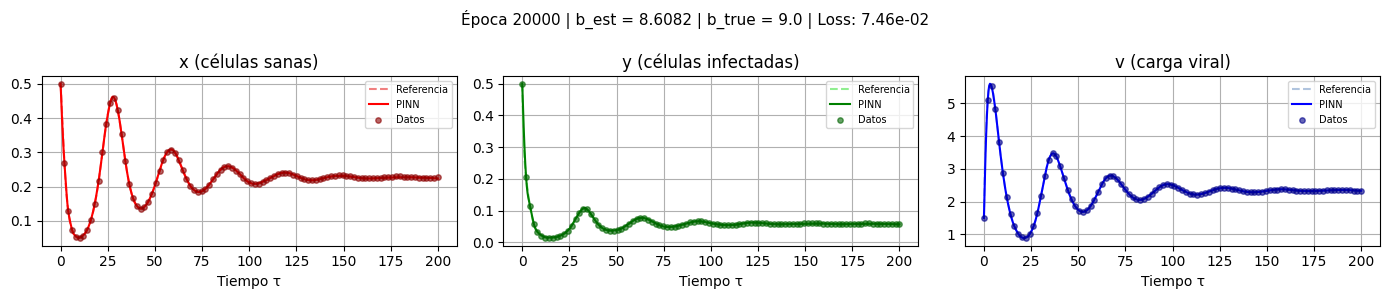

Época  25000 | Loss: 0.019692 (phys: 0.004566, data: 0.000002) | b_est = 8.6114 | t: 485.8s


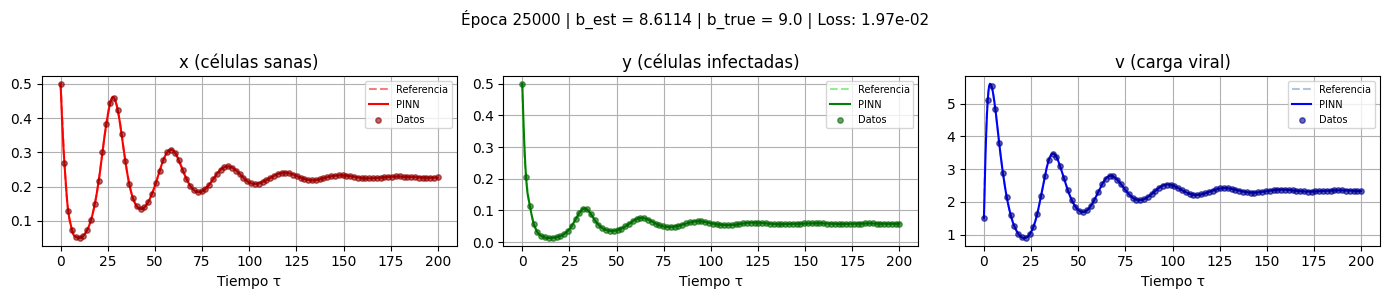

Época  30000 | Loss: 0.026536 (phys: 0.004484, data: 0.000002) | b_est = 8.6115 | t: 575.5s


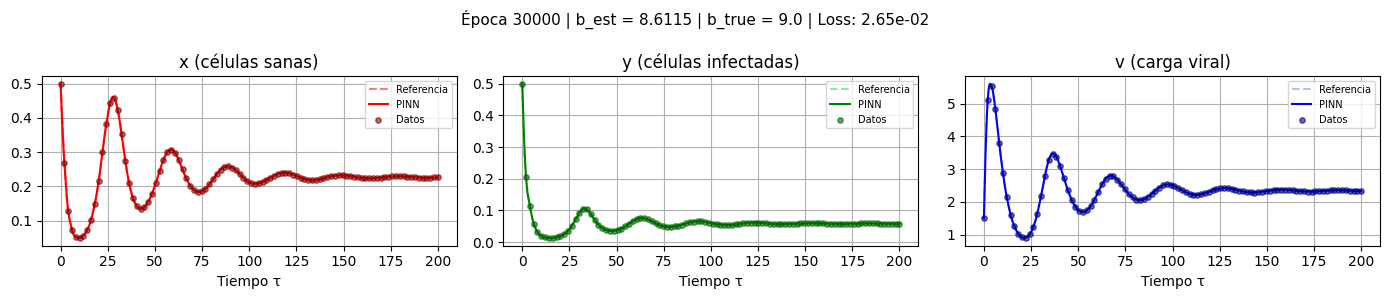


Entrenamiento finalizado en 575.8s
b estimado:      8.6115
b verdadero:     9.0
Error relativo:  4.32%


In [8]:
torch.manual_seed(123)

# Instanciamos la red neuronal
pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=4)

# Puntos de colocación física (donde se evalúan las EDOs)
N_PHYS = 1000
t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)   # más resolución para el plot

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETRO A ESTIMAR: b (tamaño de explosión viral)
# Inicializamos alejado del valor verdadero para observar la convergencia.
# b_true = 9.0  →  b_init = 1.0
# ─────────────────────────────────────────────────────────────────────────────
b_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))
bs     = []  # historial del valor de b por época
losses = []  # historial de la pérdida total

# b_param se añade al optimizador junto con los pesos de la red
optimiser = torch.optim.Adam(list(pinn.parameters()) + [b_param], lr=1e-3)

# Peso de la pérdida de datos frente a la física
lambda_data = 1e4

N_EPOCHS    = 30001
PLOT_EVERY  = 5000   # cada cuántas épocas se visualiza el ajuste

print(f"Iniciando entrenamiento: b_init = {b_param.item():.4f} | b_true = {b_true}")
print(f"Épocas: {N_EPOCHS} | Puntos físicos: {N_PHYS} | Observaciones: {N_OBS}\n")

t0 = time.time()

# Referencia densa para los plots intermedios (calculada una sola vez)
t_test_np = t_test.detach().numpy().flatten()
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r, a, b_true, c), t_eval=t_test_np, method='LSODA'
)

for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    # ── 1. PÉRDIDA FÍSICA ─────────────────────────────────────────────────
    pred_phys = pinn(t_physic)              # [N_PHYS, 3]
    xp = pred_phys[:, 0:1]
    yp = pred_phys[:, 1:2]
    vp = pred_phys[:, 2:3]

    ones = torch.ones_like(xp)
    dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
    dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
    dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

    # Residuos de las EDOs de Tian adimensionalizado:
    #   dx/dt = r·x·(1-x-y) - a·x·v
    #   dy/dt = a·x·v - y
    #   dv/dt = b·y  - a·x·v - c·v   ← b_param aparece solo aquí
    res_x = dxdt - (r * xp * (1 - xp - yp) - a * xp * vp)
    res_y = dydt - (a * xp * vp - yp)
    res_v = dvdt - (b_param * yp - a * xp * vp - c * vp)

    loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

    # ── 2. PÉRDIDA DE DATOS ───────────────────────────────────────────────
    pred_data = pinn(t_data)                # [N_OBS, 3]
    loss_data = torch.mean(
        (pred_data[:, 0:1] - x_data)**2 +
        (pred_data[:, 1:2] - y_data)**2 +
        (pred_data[:, 2:3] - v_data)**2
    )

    # ── 3. PÉRDIDA TOTAL + BACKPROP ───────────────────────────────────────
    loss = loss_phys + lambda_data * loss_data
    loss.backward()
    optimiser.step()

    bs.append(b_param.item())
    losses.append(loss.item())

    # ── 4. LOG + PLOT INTERMEDIO ──────────────────────────────────────────
    if epoch % PLOT_EVERY == 0:
        elapsed = time.time() - t0
        print(f"Época {epoch:>6} | Loss: {loss.item():.6f} "
              f"(phys: {loss_phys.item():.6f}, data: {loss_data.item():.6f}) "
              f"| b_est = {b_param.item():.4f} | t: {elapsed:.1f}s")

        # Predicción actual de la PINN (sin gradientes)
        with torch.no_grad():
            u = pinn(t_test)
            x_pred = u[:, 0].numpy()
            y_pred = u[:, 1].numpy()
            v_pred = u[:, 2].numpy()

        t_data_np = t_data.detach().numpy().flatten()

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))

        # x — células sanas
        axes[0].plot(t_test_np, sol_ref.y[0], '--', color='lightcoral',    lw=1.5, label='Referencia')
        axes[0].plot(t_test_np, x_pred,        '-',  color='red',            lw=1.5, label='PINN')
        axes[0].scatter(t_data_np, x_data.numpy().flatten(),
                        s=15, color='darkred', alpha=0.6, zorder=5, label='Datos')
        axes[0].set_title('x (células sanas)')

        # y — células infectadas
        axes[1].plot(t_test_np, sol_ref.y[1], '--', color='lightgreen',    lw=1.5, label='Referencia')
        axes[1].plot(t_test_np, y_pred,        '-',  color='green',          lw=1.5, label='PINN')
        axes[1].scatter(t_data_np, y_data.numpy().flatten(),
                        s=15, color='darkgreen', alpha=0.6, zorder=5, label='Datos')
        axes[1].set_title('y (células infectadas)')

        # v — carga viral
        axes[2].plot(t_test_np, sol_ref.y[2], '--', color='lightsteelblue', lw=1.5, label='Referencia')
        axes[2].plot(t_test_np, v_pred,        '-',  color='blue',            lw=1.5, label='PINN')
        axes[2].scatter(t_data_np, v_data.numpy().flatten(),
                        s=15, color='darkblue', alpha=0.6, zorder=5, label='Datos')
        axes[2].set_title('v (carga viral)')

        for ax in axes:
            ax.set_xlabel('Tiempo τ')
            ax.legend(fontsize=7)
            ax.grid(True)

        plt.suptitle(
            f'Época {epoch} | b_est = {b_param.item():.4f} | b_true = {b_true} '
            f'| Loss: {loss.item():.2e}',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

print(f"\nEntrenamiento finalizado en {time.time()-t0:.1f}s")
print(f"b estimado:      {b_param.item():.4f}")
print(f"b verdadero:     {b_true}")
print(f"Error relativo:  {abs(b_param.item() - b_true) / b_true * 100:.2f}%")

## Evolución del parámetro estimado `b` durante el entrenamiento

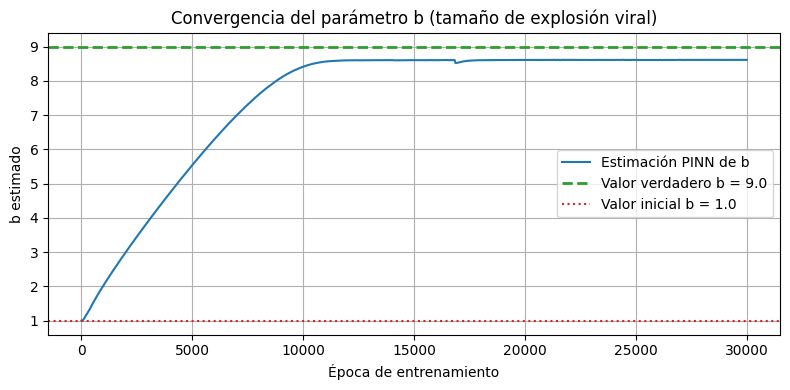


Resumen de la estimación:
  Valor inicial:   b = 0.9990
  Valor final:     b = 8.6115
  Valor verdadero: b = 9.0
  Error relativo:  4.32%


In [9]:
plt.figure(figsize=(8, 4))
plt.plot(bs, label='Estimación PINN de b', color='tab:blue', linewidth=1.5)
plt.axhline(b_true, color='tab:green', linestyle='--', linewidth=2,
            label=f'Valor verdadero b = {b_true}')
plt.axhline(bs[0], color='tab:red', linestyle=':', linewidth=1.5,
            label=f'Valor inicial b = {bs[0]:.1f}')
plt.xlabel('Época de entrenamiento')
plt.ylabel('b estimado')
plt.title('Convergencia del parámetro b (tamaño de explosión viral)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nResumen de la estimación:")
print(f"  Valor inicial:   b = {bs[0]:.4f}")
print(f"  Valor final:     b = {bs[-1]:.4f}")
print(f"  Valor verdadero: b = {b_true}")
print(f"  Error relativo:  {abs(bs[-1] - b_true) / b_true * 100:.2f}%")

## Comparación de la solución PINN vs. referencia

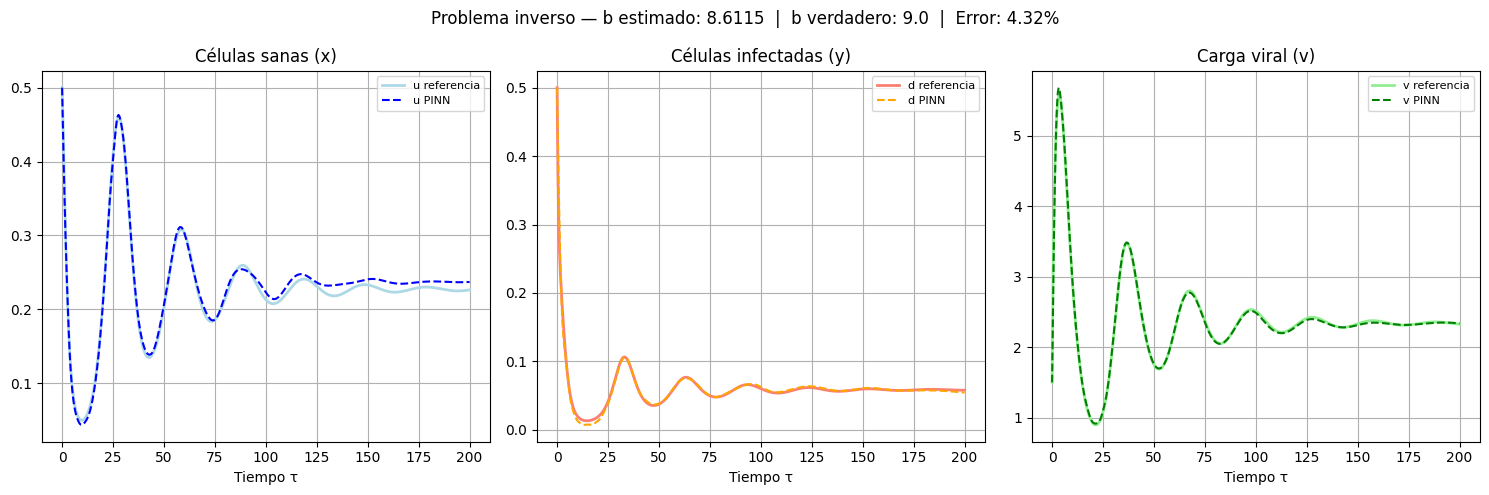

In [17]:
# ─── Solución de referencia con b_true ────────────────────────────────────
t_plot_np = np.linspace(0, TAU_MAX, 500)
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r, a, b_true, c), t_eval=t_plot_np, method='LSODA'
)

# ─── Predicción PINN ──────────────────────────────────────────────────────
t_plot = torch.tensor(t_plot_np, dtype=torch.float32).view(-1, 1)
with torch.no_grad():
    pred = pinn(t_plot)
    x_pred = pred[:, 0].numpy()
    y_pred = pred[:, 1].numpy()
    v_pred = pred[:, 2].numpy()

# ─── Gráfica ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# x — células sanas
axes[0].plot(t_plot_np, sol_ref.y[0], '-', color='lightblue',  lw=2, label='u referencia')
axes[0].plot(t_plot_np, x_pred,       '--',  color='blue',          lw=1.5, label='u PINN')
axes[0].set_title('Células sanas (x)')

# y — células infectadas
axes[1].plot(t_plot_np, sol_ref.y[1], '-', color='salmon',   lw=2, label='d referencia')
axes[1].plot(t_plot_np, y_pred,       '--',  color='orange',         lw=1.5, label='d PINN')
axes[1].set_title('Células infectadas (y)')

# v — carga viral
axes[2].plot(t_plot_np, sol_ref.y[2], '-', color='lightgreen', lw=2, label='v referencia')
axes[2].plot(t_plot_np, v_pred,       '--',  color='green',            lw=1.5, label='v PINN')
axes[2].set_title('Carga viral (v)')

for ax in axes:
    ax.set_xlabel('Tiempo τ')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f'Problema inverso — b estimado: {b_param.item():.4f}  |  b verdadero: {b_true}  '
    f'|  Error: {abs(b_param.item()-b_true)/b_true*100:.2f}%',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Estimar a

## Parámetros definidos

In [11]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
r = 0.36    # Tasa de crecimiento tumoral
b = 9.0     # Tamaño de explosión viral
c = 0.2     # Tasa de eliminación del virus

# Valor VERDADERO de a (tasa de infección adimensional) — lo que la PINN debe estimar
a_true = 0.11

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

## Problema inverso: estimar a

Iniciando entrenamiento: a_init = 1.0000 | a_true = 0.11
Épocas: 10001 | Puntos físicos: 1000 | Observaciones: 100

Época      0 | Loss: 14727.633789 (phys: 12.310053, data: 1.471532) | a_est = 1.0010 | t: 0.0s


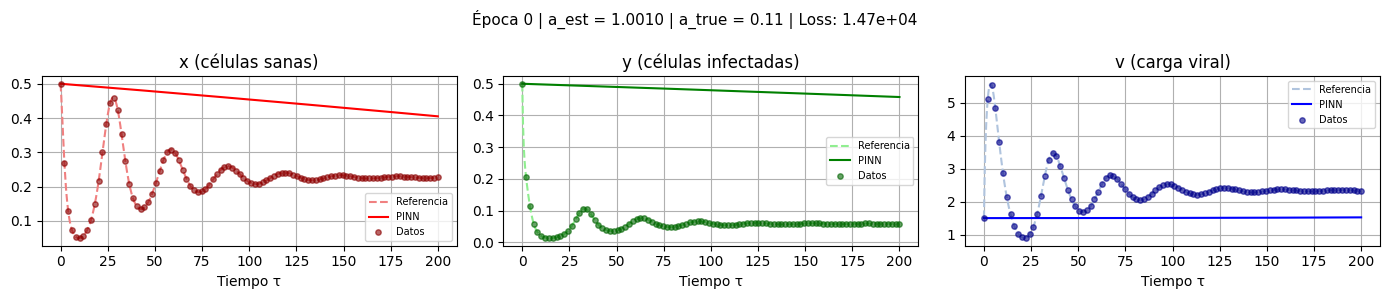

Época   5000 | Loss: 2.983586 (phys: 0.006292, data: 0.000298) | a_est = 0.1143 | t: 88.6s


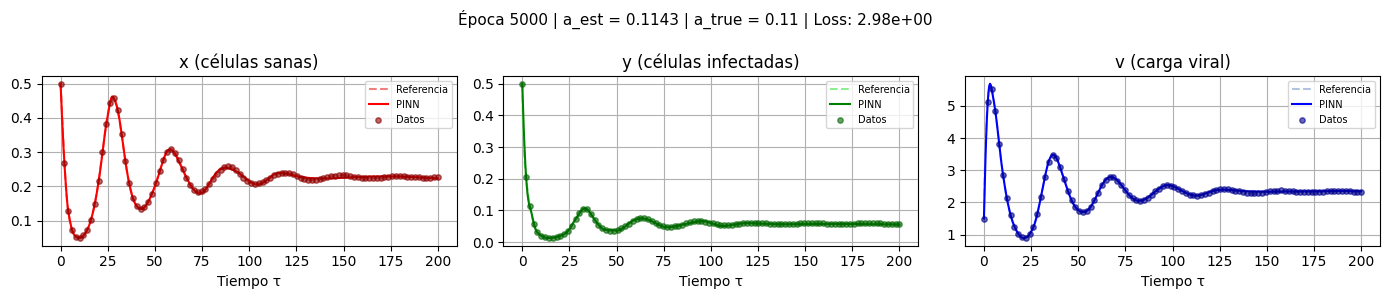

Época  10000 | Loss: 0.169195 (phys: 0.005905, data: 0.000016) | a_est = 0.1138 | t: 184.8s


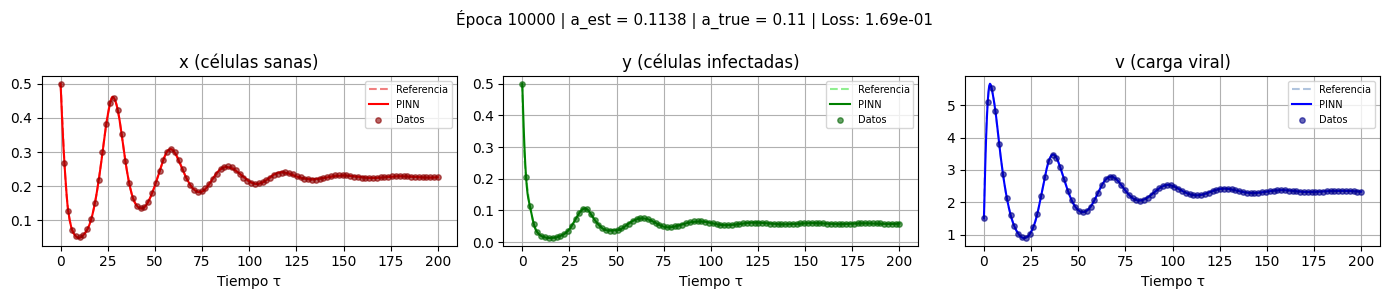


Entrenamiento finalizado en 185.0s
a estimado:      0.1138
a verdadero:     0.11
Error relativo:  3.50%


In [12]:
torch.manual_seed(123)

# Instanciamos la red neuronal
pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=4)

# Puntos de colocación física (donde se evalúan las EDOs)
N_PHYS = 1000
t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)   # más resolución para el plot

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETRO A ESTIMAR: a (tasa de infección)
# Inicializamos alejado del valor verdadero para observar la convergencia.
# Supongamos que a_true = 3.0  →  a_init = 1.0 (Ajusta a_true según tu problema)
# ─────────────────────────────────────────────────────────────────────────────
a_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))
a_vals  = []  # historial del valor de a por época
losses  = []  # historial de la pérdida total

# a_param se añade al optimizador junto con los pesos de la red
optimiser = torch.optim.Adam(list(pinn.parameters()) + [a_param], lr=1e-3)

# Peso de la pérdida de datos frente a la física
lambda_data = 1e4

N_EPOCHS    = 10001
PLOT_EVERY  = 5000   # cada cuántas épocas se visualiza el ajuste

print(f"Iniciando entrenamiento: a_init = {a_param.item():.4f} | a_true = {a_true}")
print(f"Épocas: {N_EPOCHS} | Puntos físicos: {N_PHYS} | Observaciones: {N_OBS}\n")

t0 = time.time()

# Referencia densa para los plots intermedios (calculada una sola vez)
t_test_np = t_test.detach().numpy().flatten()
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r, a_true, b, c), t_eval=t_test_np, method='LSODA' # Nota: pasamos a_true y la constante b
)

for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    # ── 1. PÉRDIDA FÍSICA ─────────────────────────────────────────────────
    pred_phys = pinn(t_physic)              # [N_PHYS, 3]
    xp = pred_phys[:, 0:1]
    yp = pred_phys[:, 1:2]
    vp = pred_phys[:, 2:3]

    ones = torch.ones_like(xp)
    dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
    dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
    dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

    # Residuos de las EDOs de Tian adimensionalizado:
    # a_param ahora aparece en las tres ecuaciones. b pasa a ser constante.
    res_x = dxdt - (r * xp * (1 - xp - yp) - a_param * xp * vp)
    res_y = dydt - (a_param * xp * vp - yp)
    res_v = dvdt - (b * yp - a_param * xp * vp - c * vp)

    loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

    # ── 2. PÉRDIDA DE DATOS ───────────────────────────────────────────────
    pred_data = pinn(t_data)                # [N_OBS, 3]
    loss_data = torch.mean(
        (pred_data[:, 0:1] - x_data)**2 +
        (pred_data[:, 1:2] - y_data)**2 +
        (pred_data[:, 2:3] - v_data)**2
    )

    # ── 3. PÉRDIDA TOTAL + BACKPROP ───────────────────────────────────────
    loss = loss_phys + lambda_data * loss_data
    loss.backward()
    optimiser.step()

    a_vals.append(a_param.item())
    losses.append(loss.item())

    # ── 4. LOG + PLOT INTERMEDIO ──────────────────────────────────────────
    if epoch % PLOT_EVERY == 0:
        elapsed = time.time() - t0
        print(f"Época {epoch:>6} | Loss: {loss.item():.6f} "
              f"(phys: {loss_phys.item():.6f}, data: {loss_data.item():.6f}) "
              f"| a_est = {a_param.item():.4f} | t: {elapsed:.1f}s")

        # Predicción actual de la PINN (sin gradientes)
        with torch.no_grad():
            u = pinn(t_test)
            x_pred = u[:, 0].numpy()
            y_pred = u[:, 1].numpy()
            v_pred = u[:, 2].numpy()

        t_data_np = t_data.detach().numpy().flatten()

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))

        # x — células sanas
        axes[0].plot(t_test_np, sol_ref.y[0], '--', color='lightcoral',    lw=1.5, label='Referencia')
        axes[0].plot(t_test_np, x_pred,        '-',  color='red',            lw=1.5, label='PINN')
        axes[0].scatter(t_data_np, x_data.numpy().flatten(),
                        s=15, color='darkred', alpha=0.6, zorder=5, label='Datos')
        axes[0].set_title('x (células sanas)')

        # y — células infectadas
        axes[1].plot(t_test_np, sol_ref.y[1], '--', color='lightgreen',    lw=1.5, label='Referencia')
        axes[1].plot(t_test_np, y_pred,        '-',  color='green',          lw=1.5, label='PINN')
        axes[1].scatter(t_data_np, y_data.numpy().flatten(),
                        s=15, color='darkgreen', alpha=0.6, zorder=5, label='Datos')
        axes[1].set_title('y (células infectadas)')

        # v — carga viral
        axes[2].plot(t_test_np, sol_ref.y[2], '--', color='lightsteelblue', lw=1.5, label='Referencia')
        axes[2].plot(t_test_np, v_pred,        '-',  color='blue',            lw=1.5, label='PINN')
        axes[2].scatter(t_data_np, v_data.numpy().flatten(),
                        s=15, color='darkblue', alpha=0.6, zorder=5, label='Datos')
        axes[2].set_title('v (carga viral)')

        for ax in axes:
            ax.set_xlabel('Tiempo τ')
            ax.legend(fontsize=7)
            ax.grid(True)

        plt.suptitle(
            f'Época {epoch} | a_est = {a_param.item():.4f} | a_true = {a_true} '
            f'| Loss: {loss.item():.2e}',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

print(f"\nEntrenamiento finalizado en {time.time()-t0:.1f}s")
print(f"a estimado:      {a_param.item():.4f}")
print(f"a verdadero:     {a_true}")
print(f"Error relativo:  {abs(a_param.item() - a_true) / a_true * 100:.2f}%")

## Definición de a

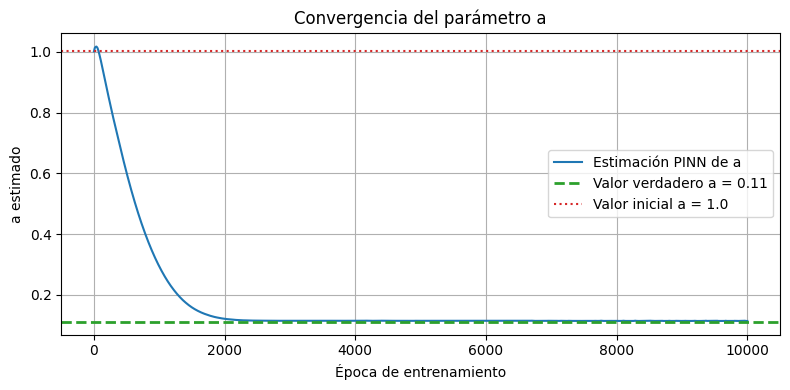


Resumen de la estimación:
  Valor inicial:   a = 1.0010
  Valor final:     a = 0.1138
  Valor verdadero: a = 0.11
  Error relativo:  3.50%


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(a_vals, label='Estimación PINN de a', color='tab:blue', linewidth=1.5)
plt.axhline(a_true, color='tab:green', linestyle='--', linewidth=2,
            label=f'Valor verdadero a = {a_true}')
plt.axhline(a_vals[0], color='tab:red', linestyle=':', linewidth=1.5,
            label=f'Valor inicial a = {a_vals[0]:.1f}')
plt.xlabel('Época de entrenamiento')
plt.ylabel('a estimado')
plt.title('Convergencia del parámetro a')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nResumen de la estimación:")
print(f"  Valor inicial:   a = {a_vals[0]:.4f}")
print(f"  Valor final:     a = {a_vals[-1]:.4f}")
print(f"  Valor verdadero: a = {a_true}")
print(f"  Error relativo:  {abs(a_vals[-1] - a_true) / a_true * 100:.2f}%")

# Estimar r

In [14]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
b = 9.0     # Tamaño de explosión viral
a = 0.11
c = 0.2     # Tasa de eliminación del virus

# Valor VERDADERO de a (tasa de crecimiento tumoral) — lo que la PINN debe estimar
r_true = 0.36

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

Iniciando entrenamiento: r_init = 1.0000 | r_true = 0.36
Épocas: 10001 | Puntos físicos: 1000 | Observaciones: 100

Época      0 | Loss: 14731.863281 (phys: 16.539324, data: 1.471532) | r_est = 1.0010 | t: 0.0s


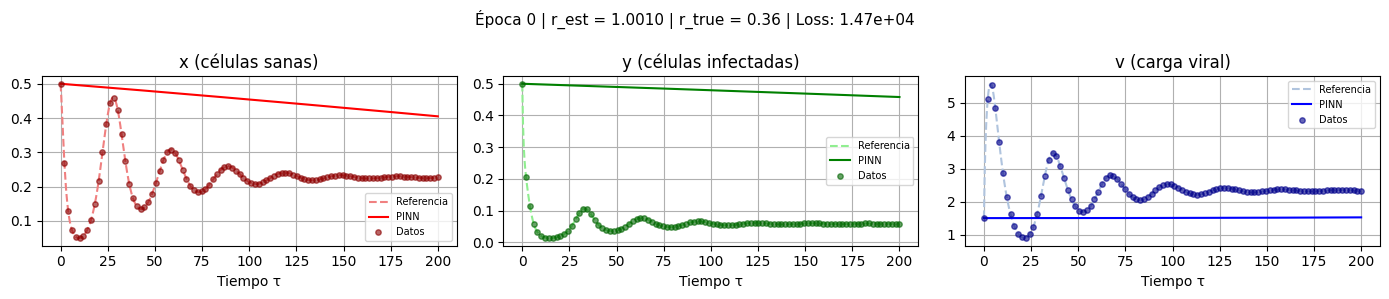

Época   5000 | Loss: 2.084572 (phys: 0.006232, data: 0.000208) | r_est = 0.3599 | t: 94.4s


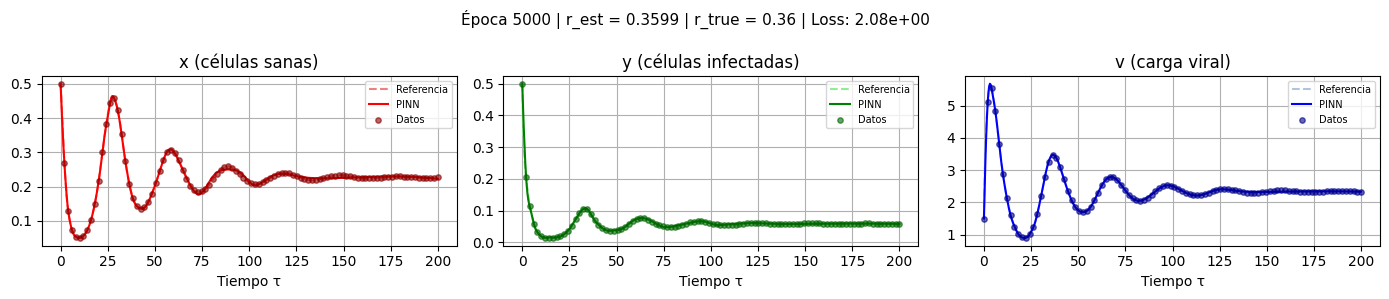

Época  10000 | Loss: 3.183478 (phys: 0.006056, data: 0.000318) | r_est = 0.3600 | t: 192.6s


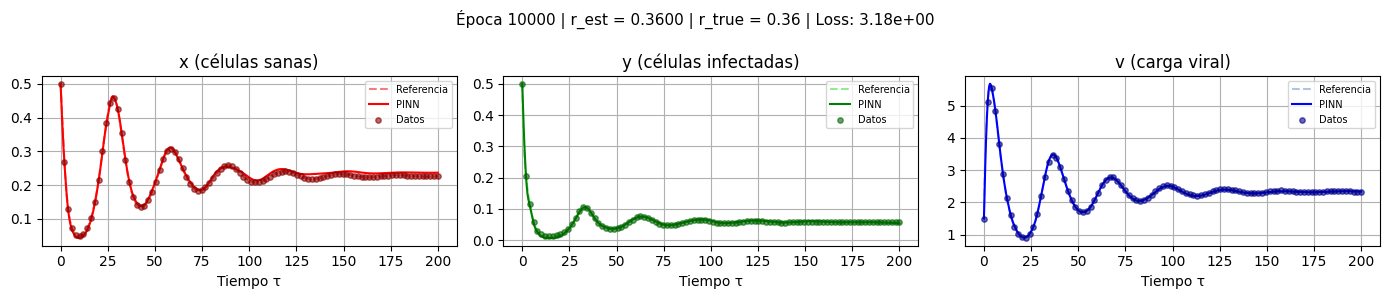


Entrenamiento finalizado en 192.8s
r estimado:      0.3600
r verdadero:     0.36
Error relativo:  0.01%


In [15]:
torch.manual_seed(123)

# Instanciamos la red neuronal
pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=4)

# Puntos de colocación física (donde se evalúan las EDOs)
N_PHYS = 1000
t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)   # más resolución para el plot

# ─────────────────────────────────────────────────────────────────────────────
# PARÁMETRO A ESTIMAR: r (tasa de crecimiento celular)
# Inicializamos alejado del valor verdadero para observar la convergencia.
# Supongamos que r_true es el valor real -> r_init = 1.0 (Ajusta r_true en tu entorno)
# ─────────────────────────────────────────────────────────────────────────────
r_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))
r_vals  = []  # historial del valor de r por época
losses  = []  # historial de la pérdida total

# r_param se añade al optimizador junto con los pesos de la red
optimiser = torch.optim.Adam(list(pinn.parameters()) + [r_param], lr=1e-3)

# Peso de la pérdida de datos frente a la física
lambda_data = 1e4

N_EPOCHS    = 10001
PLOT_EVERY  = 5000   # cada cuántas épocas se visualiza el ajuste

print(f"Iniciando entrenamiento: r_init = {r_param.item():.4f} | r_true = {r_true}")
print(f"Épocas: {N_EPOCHS} | Puntos físicos: {N_PHYS} | Observaciones: {N_OBS}\n")

t0 = time.time()

# Referencia densa para los plots intermedios (calculada una sola vez)
t_test_np = t_test.detach().numpy().flatten()
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r_true, a, b, c), t_eval=t_test_np, method='LSODA' # Nota: pasamos r_true y las constantes a, b, c
)

for epoch in range(N_EPOCHS):
    optimiser.zero_grad()

    # ── 1. PÉRDIDA FÍSICA ─────────────────────────────────────────────────
    pred_phys = pinn(t_physic)              # [N_PHYS, 3]
    xp = pred_phys[:, 0:1]
    yp = pred_phys[:, 1:2]
    vp = pred_phys[:, 2:3]

    ones = torch.ones_like(xp)
    dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
    dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
    dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

    # Residuos de las EDOs de Tian adimensionalizado:
    # r_param ahora aparece solo en la ecuación de res_x. a y b vuelven a ser constantes.
    res_x = dxdt - (r_param * xp * (1 - xp - yp) - a * xp * vp)
    res_y = dydt - (a * xp * vp - yp)
    res_v = dvdt - (b * yp - a * xp * vp - c * vp)

    loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

    # ── 2. PÉRDIDA DE DATOS ───────────────────────────────────────────────
    pred_data = pinn(t_data)                # [N_OBS, 3]
    loss_data = torch.mean(
        (pred_data[:, 0:1] - x_data)**2 +
        (pred_data[:, 1:2] - y_data)**2 +
        (pred_data[:, 2:3] - v_data)**2
    )

    # ── 3. PÉRDIDA TOTAL + BACKPROP ───────────────────────────────────────
    loss = loss_phys + lambda_data * loss_data
    loss.backward()
    optimiser.step()

    r_vals.append(r_param.item())
    losses.append(loss.item())

    # ── 4. LOG + PLOT INTERMEDIO ──────────────────────────────────────────
    if epoch % PLOT_EVERY == 0:
        elapsed = time.time() - t0
        print(f"Época {epoch:>6} | Loss: {loss.item():.6f} "
              f"(phys: {loss_phys.item():.6f}, data: {loss_data.item():.6f}) "
              f"| r_est = {r_param.item():.4f} | t: {elapsed:.1f}s")

        # Predicción actual de la PINN (sin gradientes)
        with torch.no_grad():
            u = pinn(t_test)
            x_pred = u[:, 0].numpy()
            y_pred = u[:, 1].numpy()
            v_pred = u[:, 2].numpy()

        t_data_np = t_data.detach().numpy().flatten()

        fig, axes = plt.subplots(1, 3, figsize=(14, 3))

        # x — células sanas
        axes[0].plot(t_test_np, sol_ref.y[0], '--', color='lightcoral',    lw=1.5, label='Referencia')
        axes[0].plot(t_test_np, x_pred,        '-',  color='red',            lw=1.5, label='PINN')
        axes[0].scatter(t_data_np, x_data.numpy().flatten(),
                        s=15, color='darkred', alpha=0.6, zorder=5, label='Datos')
        axes[0].set_title('x (células sanas)')

        # y — células infectadas
        axes[1].plot(t_test_np, sol_ref.y[1], '--', color='lightgreen',    lw=1.5, label='Referencia')
        axes[1].plot(t_test_np, y_pred,        '-',  color='green',          lw=1.5, label='PINN')
        axes[1].scatter(t_data_np, y_data.numpy().flatten(),
                        s=15, color='darkgreen', alpha=0.6, zorder=5, label='Datos')
        axes[1].set_title('y (células infectadas)')

        # v — carga viral
        axes[2].plot(t_test_np, sol_ref.y[2], '--', color='lightsteelblue', lw=1.5, label='Referencia')
        axes[2].plot(t_test_np, v_pred,        '-',  color='blue',            lw=1.5, label='PINN')
        axes[2].scatter(t_data_np, v_data.numpy().flatten(),
                        s=15, color='darkblue', alpha=0.6, zorder=5, label='Datos')
        axes[2].set_title('v (carga viral)')

        for ax in axes:
            ax.set_xlabel('Tiempo τ')
            ax.legend(fontsize=7)
            ax.grid(True)

        plt.suptitle(
            f'Época {epoch} | r_est = {r_param.item():.4f} | r_true = {r_true} '
            f'| Loss: {loss.item():.2e}',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

print(f"\nEntrenamiento finalizado en {time.time()-t0:.1f}s")
print(f"r estimado:      {r_param.item():.4f}")
print(f"r verdadero:     {r_true}")
print(f"Error relativo:  {abs(r_param.item() - r_true) / r_true * 100:.2f}%")

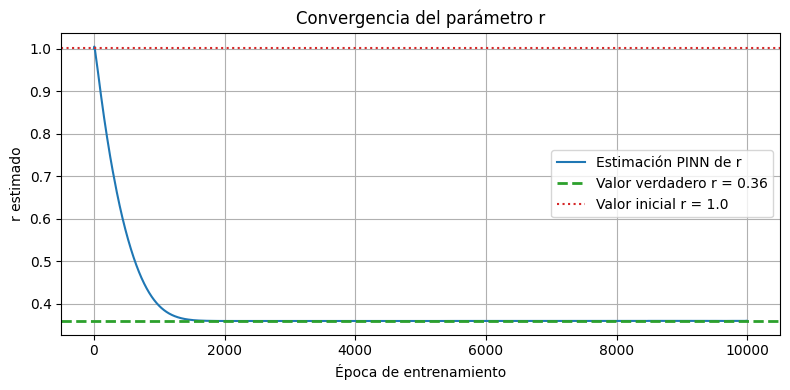


Resumen de la estimación:
  Valor inicial:   r = 1.0010
  Valor final:     r = 0.3600
  Valor verdadero: r = 0.36
  Error relativo:  0.01%


In [16]:
plt.figure(figsize=(8, 4))
plt.plot(r_vals, label='Estimación PINN de r', color='tab:blue', linewidth=1.5)
plt.axhline(r_true, color='tab:green', linestyle='--', linewidth=2,
            label=f'Valor verdadero r = {r_true}')
plt.axhline(r_vals[0], color='tab:red', linestyle=':', linewidth=1.5,
            label=f'Valor inicial r = {r_vals[0]:.1f}')
plt.xlabel('Época de entrenamiento')
plt.ylabel('r estimado')
plt.title('Convergencia del parámetro r')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nResumen de la estimación:")
print(f"  Valor inicial:   r = {r_vals[0]:.4f}")
print(f"  Valor final:     r = {r_vals[-1]:.4f}")
print(f"  Valor verdadero: r = {r_true}")
print(f"  Error relativo:  {abs(r_vals[-1] - r_true) / r_true * 100:.2f}%")